In [1]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [4]:
df=pd.read_csv(r"C:\Users\HP\Downloads\car data (1).csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [8]:
df.shape

(301, 9)

In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
df=df.drop_duplicates()

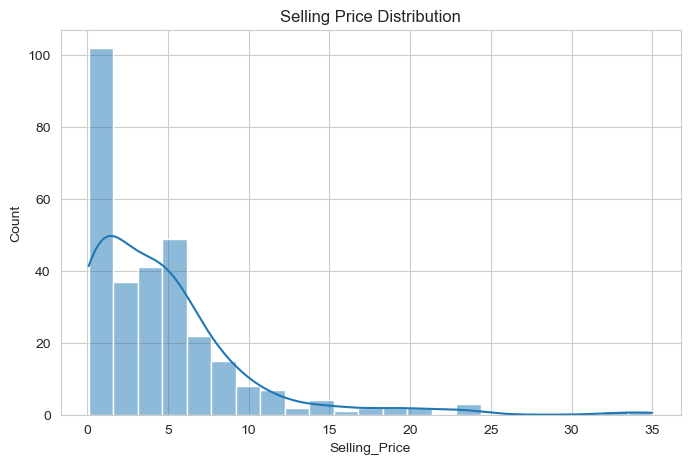

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

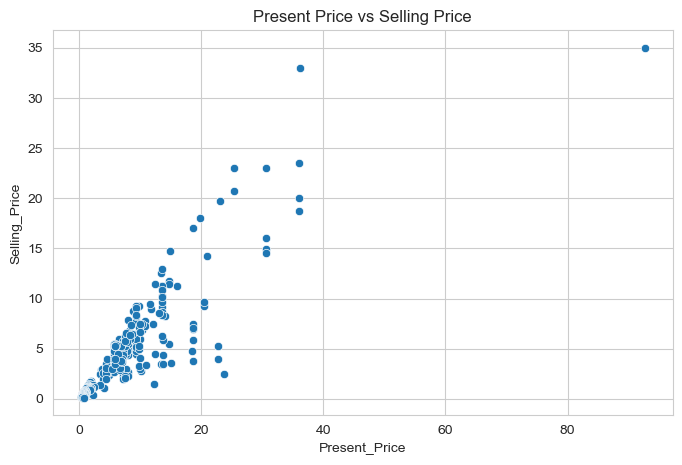

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title("Present Price vs Selling Price")
plt.show()

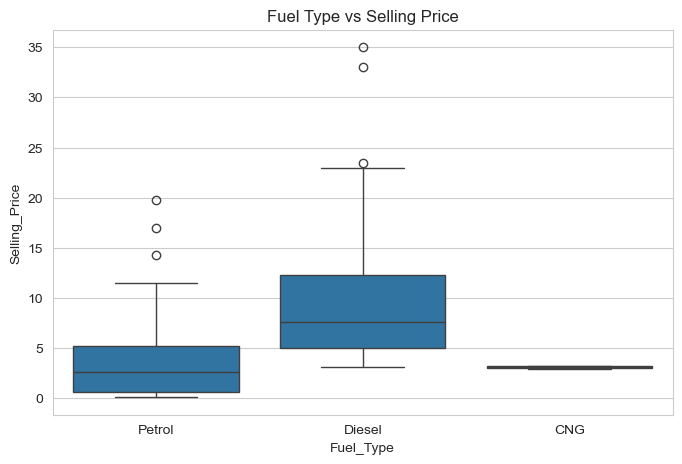

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

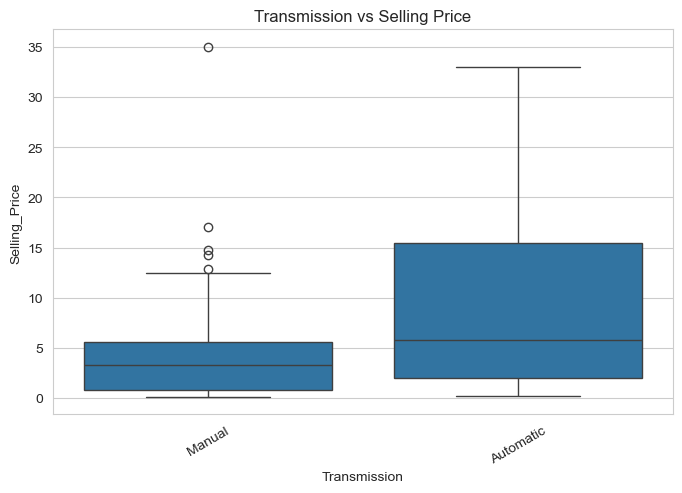

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.xticks(rotation=30)
plt.title("Transmission vs Selling Price")
plt.show()

In [19]:
df = df.drop('Car_Name', axis=1)  # Drop non-useful column
df = pd.get_dummies(df, drop_first=True)

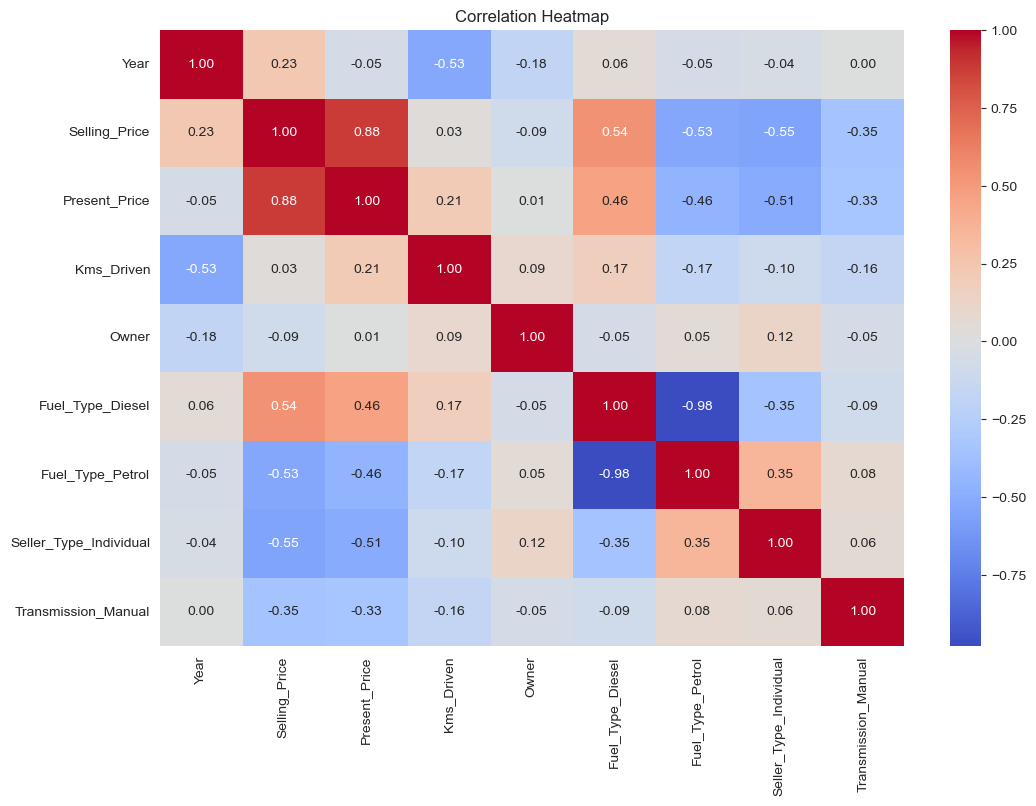

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [21]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Running Linear Regression...")

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))

Running Linear Regression...
Linear Regression R2 Score: 0.7528154215828856


In [24]:
from sklearn.ensemble import RandomForestRegressor

print("Running Random Forest...")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Running Random Forest...
Random Forest R2 Score: 0.5244342943414741


In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("\nLinear Regression R2:", r2_score(y_test, lr.predict(X_test)))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest R2:", r2_score(y_test, rf.predict(X_test)))


Linear Regression R2: 0.7528154215828856
Random Forest R2: 0.5244342943414741


In [26]:
import pickle

columns = X_train.columns  # ✅ Define columns HERE, after split & encoding

pickle.dump(rf, open("car_model.pkl", "wb"))
pickle.dump(columns, open("car_columns.pkl", "wb"))

print("\nModel Saved Successfully")


Model Saved Successfully


In [27]:
sample = X_test.iloc[0:1]
prediction = rf.predict(sample)

print("\nSample Prediction:", prediction)


Sample Prediction: [9.4234]


In [28]:
import os

streamlit_code = """
import streamlit as st
import pickle
import pandas as pd

with open('car_model.pkl', 'rb') as model_file:
    model = pickle.load(model_file)

with open('car_columns.pkl', 'rb') as columns_file:
    columns = pickle.load(columns_file)

st.title('Car Selling Price Prediction App')

year = st.number_input('Year of Manufacture', min_value=2000, max_value=2024, value=2015, step=1)
present_price = st.number_input('Present Showroom Price (in Lakhs)', min_value=0.5, value=5.0, step=0.1)
kms_driven = st.number_input('Kilometers Driven', min_value=100, value=30000, step=500)
owner = st.selectbox('Number of Previous Owners', [0, 1, 2, 3])
fuel_type = st.selectbox('Fuel Type', ['Petrol', 'Diesel', 'CNG'])
seller_type = st.selectbox('Seller Type', ['Dealer', 'Individual'])
transmission = st.selectbox('Transmission', ['Manual', 'Automatic'])
if st.button('Predict Selling Price'):

    input_data = pd.DataFrame({
        'Year': [year],
        'Present_Price': [present_price],
        'Kms_Driven': [kms_driven],
        'Owner': [owner],
        'Fuel_Type_Diesel': [1 if fuel_type == 'Diesel' else 0],
        'Fuel_Type_Petrol': [1 if fuel_type == 'Petrol' else 0],
        'Seller_Type_Individual': [1 if seller_type == 'Individual' else 0],
        'Transmission_Manual': [1 if transmission == 'Manual' else 0],
    })

    for col in columns:
        if col not in input_data.columns:
            input_data[col] = 0

    input_data = input_data[columns]

    predicted_price = model.predict(input_data)

    st.success(f'Predicted Selling Price: Rs. {predicted_price[0]:.2f} Lakhs')
"""

file_path = os.path.join(os.getcwd(), 'carpriceapp.py')

try:
    with open(file_path, 'w', encoding='utf-8') as file:
        file.write(streamlit_code)
    print(f"File '{file_path}' has been saved successfully.")
except Exception as e:
    print(f"Error saving file: {e}")

File 'C:\Users\HP\carpriceapp.py' has been saved successfully.
